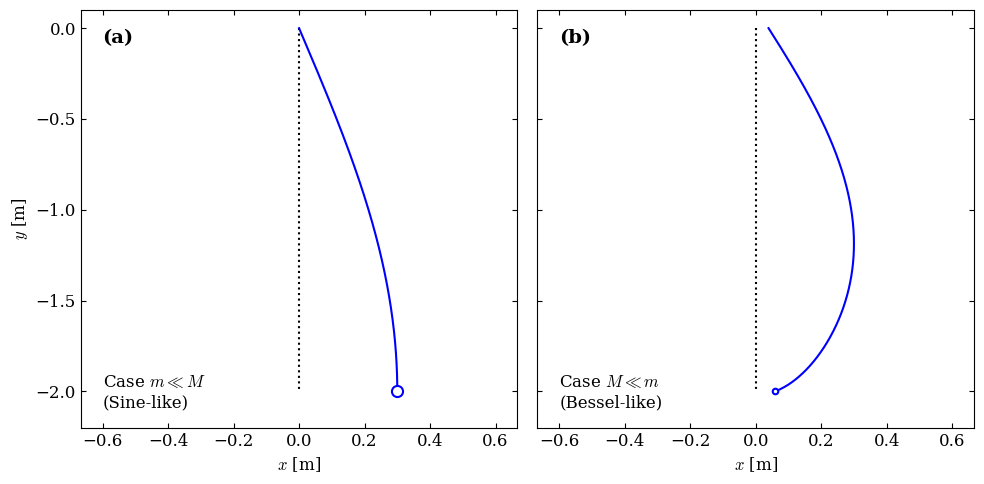

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv, yv # For Bessel functions J_0 and Y_0

# --- CONFIGURACIÓN DE ESTILO DE PUBLICACIÓN  ---
# Esto ajusta matplotlib para que se vea como el European Journal of Physics
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",      # Usa la fuente matemática de LaTeX (Computer Modern)
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 10,
    "xtick.direction": "in",       # Ticks apuntando hacia adentro
    "ytick.direction": "in",
    "xtick.top": True,             # Ticks también arriba
    "ytick.right": True,           # Ticks también a la derecha
    "lines.linewidth": 1.5,
    "axes.grid": False,            # El paper de referencia NO usa grid, se ve más limpio
})

# --- Define fixed parameters---
L = 2.0   # Length of the string (m)
g = 9.81  # Acceleration due to gravity (m/s^2)

# --- Define the function for rho(y) ---
def rho(y_val, M_val, m_val, omega_val, A_coeff, B_coeff):
    """
    Calculates rho(y) based on the Bessel function solution.
    y_val: position along the string (from 0 to L)
    M_val: hanging mass
    m_val: mass per unit length
    omega_val: angular frequency of the mode
    A_coeff, B_coeff: constants determined by boundary conditions
    """
    
    # Calculate the argument for Bessel functions
    # Note: the definition of z in your text might have a slight typo in the Bessel argument,
    # it typically involves sqrt(omega^2/g) * sqrt(z) or similar, but I'll stick to your provided formula.
    # From your provided equation: sqrt(omega^2 L / g m) * z
    # Let's ensure the argument inside J0 and Y0 is correctly handled.
    # It seems your u(z) definition is: u(z) = A J_0(k*z) + B Y_0(k*z) where k = sqrt(omega^2 L / g m)
    # And rho(y) = sqrt(z) * u(z)
    
    # First, calculate z
    z_val = M_val + (m_val / L) * (L - y_val)
    
    # Calculate the argument for Bessel functions (let's call it 'arg')
    # Make sure omega_val is such that the term under sqrt is positive.
    # The term sqrt(omega^2 L / g m) is a constant for a given mode and system.
    k_bessel = np.sqrt( (omega_val**2 * L) / (g * m_val) )
    
    arg = k_bessel * z_val
    
    # Calculate u(z)
    u_z = A_coeff * jv(0, arg) + B_coeff * yv(0, arg)
    
    # Calculate rho(y)
    rho_y = np.sqrt(z_val) * u_z
    
    return rho_y

# --- Plotting Setup ---
y_values = np.linspace(0, L, 500) # Points along the string

# Variable auxiliar para ploteo vertical (0 arriba, -L abajo)
y_plot = -y_values 

# --- CONCEPTUAL PLOTS ---

# Figure setup (Estilo Script B: Vertical, sharey)
fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharey=True)
plt.subplots_adjust(wspace=0.15) 

# --- Case 1: m << M (String mass negligible) ---
# Conceptually, this should look like a sine wave (fixed at y=0, free at y=L for fundamental)
# For simplicity, let's plot a sine wave that satisfies a fixed end at y=0 and an antinode (max amplitude) at the pendulum mass M (y=L).
# This is a conceptual representation, not derived from Bessel functions here.
# A fundamental mode of a fixed-free string is a quarter wavelength.
# So, sin(pi/2 * y/L) for the fundamental.

ax1 = axs[0] # Usamos ax1 en lugar de plt.subplot

M_large = 100.0 # kg
m_small = 0.01  # kg/m

# Hypothetical sine wave for the fundamental mode (conceptual)
# Assuming fixed at y=0, and M is at y=L. The string mode would be a standing wave.
# If the mass M is acting as the primary oscillator, the string might just follow it.
# If we consider the string's own modes, and M acts as a fixed point at y=L for vibration,
# or a "free" end depending on how M interacts.
# Let's assume a simplified "fixed at y=0, free at y=L" string for illustration of harmonic shape.
# For fundamental mode (1/4 wavelength): A sin(pi*y/(2*L))
amp_m_small = 0.1 # Arbitrary amplitude for visualization (ORIGINAL PARAMETER)
# Aumentamos un poco la amplitud visual solo para que se vea bien en el formato vertical
VISUAL_SCALE = 3.0 
rho_m_small_conceptual = (amp_m_small * VISUAL_SCALE) * np.sin(np.pi / (2 * L) * y_values)
# Or, if M is the primary oscillator, string just stretches. But it asks for string normal mode.
# So, the conceptual shape is indeed sinusoidal.

# --- PLOTTING LOGIC---
# 1. Equilibrium
ax1.plot([0, 0], [0, -L], 'k:', linewidth=1.5, label='Equilibrium')
# 2. Shape (swapping x and y for vertical orientation)
ax1.plot(rho_m_small_conceptual, y_plot, 'b-', label='Mode Shape')
# 3. Mass M marker
ax1.plot(rho_m_small_conceptual[-1], y_plot[-1], 'o', markersize=8, markerfacecolor='white', markeredgecolor='b', markeredgewidth=1.5)

ax1.set_xlabel(r'$x$ [m]') # Amplitude is now on x-axis
ax1.set_ylabel(r'$y$ [m]') # Position is now on y-axis
ax1.set_title('') # Quitamos titulo por defecto para usar formato (a)
ax1.text(0.05, 0.92, '(a)', transform=ax1.transAxes, fontsize=14, fontweight='bold')
ax1.text(0.05, 0.05, r'Case $m \ll M$' + '\n(Sine-like)', transform=ax1.transAxes, fontsize=12)
ax1.set_xlim(-L/3, L/3) # Ajuste visual
ax1.set_ylim(-L*1.1, 0.1)


# --- Case 2: M << m (Hanging Mass negligible) ---
ax2 = axs[1] # Usamos ax2

M_small = 0.01 # kg
m_large = 1.0  # kg/m

# For this case, we'd need actual A, B, omega_n values.
# Since we don't have them, I will just create a placeholder plot
# or use a simplified Bessel form to show the general varying wavelength characteristic.
# Y_0 diverges at 0, so B is often 0 for boundary conditions at z=0 (which is y=L if M is negligible)
# If y=L means z=M, and M is very small, z approaches 0.
# So, often B=0 is chosen to avoid divergence at the free end.
# If B=0, then rho(y) = sqrt(z) * A * J_0(k*z)

# Let's pick an arbitrary omega and A for illustration
# You'd need to solve the eigenvalue problem to get correct omega_n and A, B.
# This is PURELY illustrative of a Bessel-like shape, not an actual solution.
hypothetical_omega_M_small = 5.0 # rad/s (arbitrary)
hypothetical_A_M_small = 0.5 # arbitrary

# We need to handle the case where z_val might be very close to zero for y=L
# For practical plotting, ensure z_val is never exactly zero if using yv which diverges at 0.
# The domain for z is [M, M+m]. y=L corresponds to z=M.
# So y_values from 0 to L maps to z_values from M+m to M.
# The argument for Bessel functions will range from k*(M+m) down to k*M.
# If M is very small, k*M will be very small.

z_values_M_small = M_small + (m_large / L) * (L - y_values)

# Filter out z_values that might cause issues for yv if M_small is exactly 0 and y_values exactly L
# In a real scenario, M_small would not be exactly 0, preventing true divergence.
# For numerical stability, ensure arg is never exactly 0 for Y_0.
# Let's just plot J_0 term, assuming B=0 for now for illustration.
k_bessel_M_small = np.sqrt( (hypothetical_omega_M_small**2 * L) / (g * m_large) )
arg_M_small = k_bessel_M_small * z_values_M_small

# If M_small is very small, z_values_M_small will approach 0 at y=L.
# J_0(x) approaches 1 as x -> 0. Y_0(x) approaches -infinity as x -> 0.
# So if the boundary condition implies finite displacement at M, B must be 0.
raw_shape_bessel = np.sqrt(z_values_M_small) * jv(0, arg_M_small)

# Normalizamos visualmente para que se parezca en escala al panel (a)
rho_M_small_conceptual = (amp_m_small * VISUAL_SCALE) * (raw_shape_bessel / np.max(np.abs(raw_shape_bessel)))

# --- PLOTTING LOGIC ---
# 1. Equilibrium
ax2.plot([0, 0], [0, -L], 'k:', linewidth=1.5, label='Equilibrium')
# 2. Shape
ax2.plot(rho_M_small_conceptual, y_plot, 'b-', label='Mode Shape')
# 3. Mass M marker (small dot)
ax2.plot(rho_M_small_conceptual[-1], y_plot[-1], 'o', markersize=4, markerfacecolor='white', markeredgecolor='b', markeredgewidth=1.5)

ax2.set_xlabel(r'$x$ [m]')
ax2.set_title('')
ax2.text(0.05, 0.92, '(b)', transform=ax2.transAxes, fontsize=14, fontweight='bold')
ax2.text(0.05, 0.05, r'Case $M \ll m$' + '\n(Bessel-like)', transform=ax2.transAxes, fontsize=12)
ax2.set_xlim(-L/3, L/3) 

# plt.legend() 

plt.savefig("contoniusplot.pdf") 
plt.tight_layout()
plt.show()